Descargar y visualizar el dataset

In [1]:
!pip install medmnist
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.3 MB/s eta 0:00:00


In [2]:
import os
from medmnist import PneumoniaMNIST

In [3]:
# Directorio actual donde se está ejecutando Jupyter
PROJECT_DIR = os.getcwd()

# Crear /data dentro del proyecto
DATA_DIR = os.path.join(PROJECT_DIR, "data")

# Tamano de las imagenes
IMAGE_SIZE = 28

os.makedirs(DATA_DIR, exist_ok=True)

print("Proyecto:", PROJECT_DIR)
print("Dataset:", DATA_DIR)

Proyecto: /content
Dataset: /content/data


In [4]:
# Training data
train_dataset = PneumoniaMNIST(
    split="train",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=True
)

# Validation data
val_dataset = PneumoniaMNIST(
    split="val",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=True
)

# Test data
test_dataset = PneumoniaMNIST(
    split="test",
    root=DATA_DIR,
    size=128,
    download=True
)

100%|██████████| 4.17M/4.17M [00:00<00:00, 6.77MB/s]
100%|██████████| 75.5M/75.5M [00:06<00:00, 12.1MB/s]


In [5]:
# --- Cargar las variables ----

import os
from medmnist import PneumoniaMNIST

DATA_DIR = "./data"

train_dataset = PneumoniaMNIST(
    split="train",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

val_dataset = PneumoniaMNIST(
    split="val",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

test_dataset = PneumoniaMNIST(
    split="test",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

print("Archivos:", os.listdir(DATA_DIR))

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("Archivos:", os.listdir(DATA_DIR))

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Archivos: ['pneumoniamnist.npz', 'pneumoniamnist_128.npz']
Train: 4708
Validation: 524
Test: 624
Archivos: ['pneumoniamnist.npz', 'pneumoniamnist_128.npz']
Train: 4708
Validation: 524
Test: 624


Visualizar data set

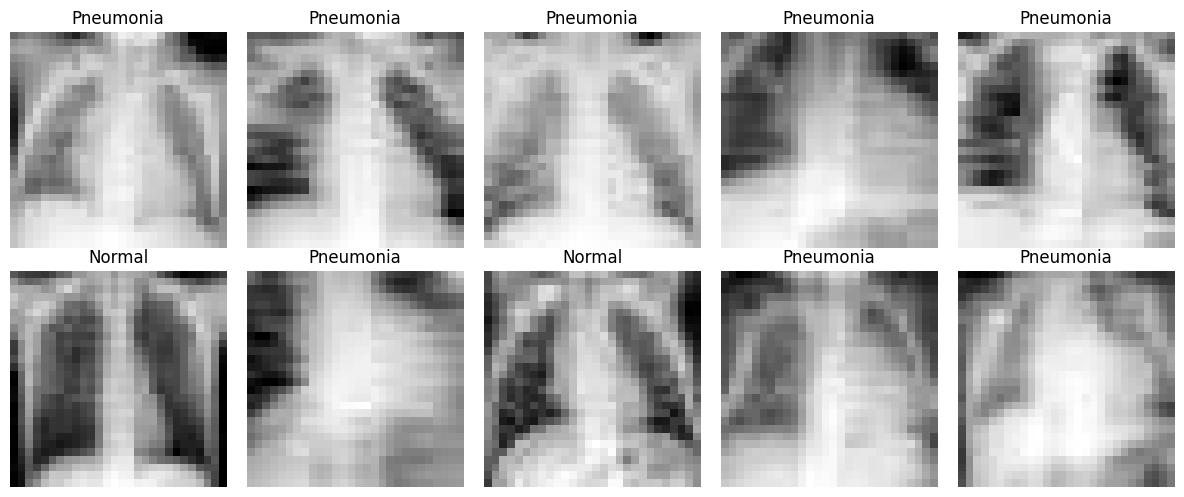

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image, cmap="gray")

    clase = "Normal" if label.item() == 0 else "Pneumonia"
    ax.set_title(clase)

    ax.axis("off")

plt.tight_layout()
plt.show()

Debemos saber si el dataset esta balanceado

In [7]:
import numpy as np

labels = train_dataset.labels.flatten()

clases, cantidades = np.unique(labels, return_counts=True)

for clase, cantidad in zip(clases, cantidades):
    nombre = "Normal" if clase == 0 else "Pneumonia"
    porcentaje = cantidad / len(labels) * 100

    print(f"{nombre}: {cantidad} ({porcentaje:.2f}%)")

Normal: 1214 (25.79%)
Pneumonia: 3494 (74.21%)


## Balancear el conjunto de entrenamiento

Se conservan todas las imágenes normales y se selecciona aleatoriamente la misma cantidad de imágenes con neumonía. La semilla permite reproducir la selección. Este proceso no elimina ni modifica los archivos originales del dataset.

In [8]:
from torch.utils.data import Subset

SEMILLA = 42

# Conservar una referencia al dataset completo, incluso si esta celda se ejecuta otra vez.
if not isinstance(train_dataset, Subset):
    train_dataset_completo = train_dataset

labels_completos = np.asarray(train_dataset_completo.labels).reshape(-1)
indices_normales = np.flatnonzero(labels_completos == 0)
indices_neumonia = np.flatnonzero(labels_completos == 1)

if len(indices_neumonia) < len(indices_normales):
    raise ValueError("No hay suficientes imágenes de neumonía para igualar la clase normal.")

rng = np.random.default_rng(SEMILLA)
indices_neumonia_seleccionados = rng.choice(
    indices_neumonia,
    size=len(indices_normales),
    replace=False
)

indices_balanceados = np.concatenate([
    indices_normales,
    indices_neumonia_seleccionados
])
rng.shuffle(indices_balanceados)

# A partir de aquí, train_dataset es el conjunto balanceado que se debe entrenar.
train_dataset = Subset(train_dataset_completo, indices_balanceados.tolist())

# Verificar el resultado.
labels_balanceados = labels_completos[indices_balanceados]
clases, cantidades = np.unique(labels_balanceados, return_counts=True)

print(f"Total de entrenamiento balanceado: {len(train_dataset)}")
for clase, cantidad in zip(clases, cantidades):
    nombre = "Normal" if clase == 0 else "Pneumonia"
    porcentaje = cantidad / len(labels_balanceados) * 100
    print(f"{nombre}: {cantidad} ({porcentaje:.2f}%)")

Total de entrenamiento balanceado: 2428
Normal: 1214 (50.00%)
Pneumonia: 1214 (50.00%)


# Entrenamiento de las muestras balanceado

Basado en los ejemplos de la librería, vamos a entrenar un modelo que pueda predecir si dada una imagen esta presenta neumonía o no.

Tomado y adaptado de: https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb

## Preparar los datos para PyTorch

Las imágenes se convierten a tensores y se normalizan igual que en el ejemplo oficial. El `DataLoader` de entrenamiento usa el subconjunto balanceado creado anteriormente; validación y prueba permanecen completos para medir el rendimiento sobre la distribución original.

In [9]:
import random
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, roc_auc_score

# Hiperparámetros
SEMILLA = 42
NUM_EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.001

# Reproducibilidad
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

# Usar GPU cuando esté disponible.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# El Subset balanceado aplica el transform de su dataset base.
train_dataset_completo.transform = data_transform
val_dataset.transform = data_transform
test_dataset.transform = data_transform

generador = torch.Generator().manual_seed(SEMILLA)
usar_pin_memory = DEVICE.type == "cuda"

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generador,
    num_workers=0,
    pin_memory=usar_pin_memory
)
train_loader_eval = data.DataLoader(
    train_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)
val_loader = data.DataLoader(
    val_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)

print("Dispositivo:", DEVICE)
print("Train balanceado:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Dispositivo: cpu
Train balanceado: 2428
Validation: 524
Test: 624


## Definir la red neuronal

Esta CNN sigue la arquitectura del cuaderno oficial para imágenes de 28 × 28. La salida tiene dos valores: clase 0 (`Normal`) y clase 1 (`Pneumonia`).

In [10]:
class PneumoniaCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)


model = PneumoniaCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

PneumoniaCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, 

## Entrenar el modelo

In [11]:
historial = {"loss": [], "val_loss": [], "acc": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    perdida_acumulada = 0.0
    correctas = 0
    total = 0

    barra = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    for images, targets in barra:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.view(-1).long().to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        cantidad = targets.size(0)
        perdida_acumulada += loss.item() * cantidad
        correctas += (outputs.argmax(dim=1) == targets).sum().item()
        total += cantidad
        barra.set_postfix(loss=f"{perdida_acumulada / total:.4f}")

    epoch_loss = perdida_acumulada / total
    epoch_acc = correctas / total

    # Calcular la pérdida de validación sin actualizar los pesos.
    model.eval()
    perdida_val_acumulada = 0.0
    total_val = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.view(-1).long().to(DEVICE, non_blocking=True)
            outputs = model(images)
            val_loss = criterion(outputs, targets)
            perdida_val_acumulada += val_loss.item() * targets.size(0)
            total_val += targets.size(0)

    epoch_val_loss = perdida_val_acumulada / total_val
    historial["loss"].append(epoch_loss)
    historial["val_loss"].append(epoch_val_loss)
    historial["acc"].append(epoch_acc)
    print(
        f"Epoch {epoch + 1:02d} - train_loss: {epoch_loss:.4f} "
        f"- val_loss: {epoch_val_loss:.4f} - train_acc: {epoch_acc:.4f}"
    )

Epoch 1/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 - train_loss: 0.2669 - val_loss: 1.8437 - train_acc: 0.8826


Epoch 2/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 02 - train_loss: 0.1318 - val_loss: 0.1373 - train_acc: 0.9485


Epoch 3/30:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 28 - train_loss: 0.0000 - val_loss: 0.1192 - train_acc: 1.0000


Epoch 29/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 29 - train_loss: 0.0000 - val_loss: 0.1216 - train_acc: 1.0000


Epoch 30/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 30 - train_loss: 0.0000 - val_loss: 0.1217 - train_acc: 1.0000


## Curva de pérdida

La convergencia se observa cuando la pérdida deja de disminuir de forma importante. Si la pérdida de entrenamiento continúa bajando mientras la de validación empieza a subir, es una señal de sobreajuste.

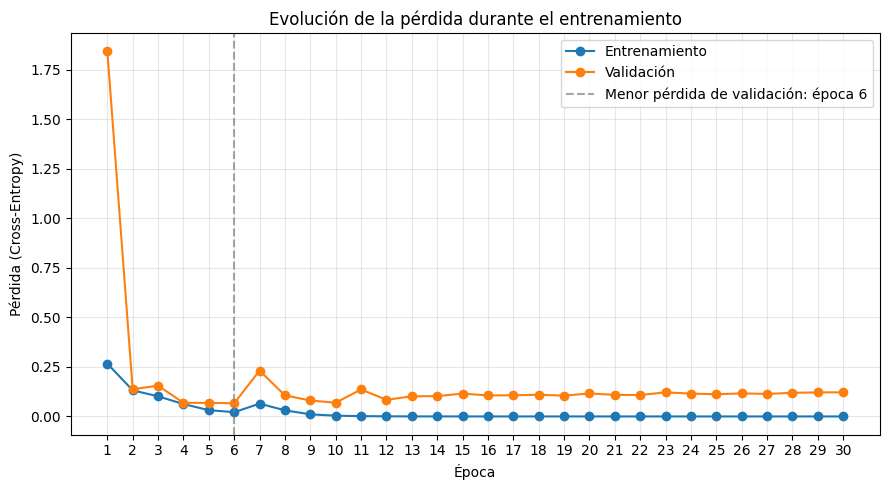

Menor pérdida de validación en la época 6: 0.0665


In [12]:
epocas = np.arange(1, NUM_EPOCHS + 1)
mejor_epoca = int(np.argmin(historial["val_loss"])) + 1

plt.figure(figsize=(9, 5))
plt.plot(epocas, historial["loss"], marker="o", label="Entrenamiento")
plt.plot(epocas, historial["val_loss"], marker="o", label="Validación")
plt.axvline(
    mejor_epoca,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Menor pérdida de validación: época {mejor_epoca}"
)
plt.xlabel("Época")
plt.ylabel("Pérdida (Cross-Entropy)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xticks(epocas)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Menor pérdida de validación en la época {mejor_epoca}: "
    f"{historial['val_loss'][mejor_epoca - 1]:.4f}"
)

## Evaluar AUC y accuracy

`Evaluator` de MedMNIST compara contra el número fijo de ejemplos del conjunto oficial y por eso no acepta directamente el `Subset` balanceado. La siguiente función calcula las mismas métricas usando las etiquetas y predicciones de cada `DataLoader`.

In [13]:
def evaluar_modelo(data_loader):
    model.eval()
    etiquetas = []
    probabilidades = []
    predicciones = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            probs_neumonia = torch.softmax(outputs, dim=1)[:, 1]

            etiquetas.extend(targets.view(-1).cpu().numpy())
            probabilidades.extend(probs_neumonia.cpu().numpy())
            predicciones.extend(outputs.argmax(dim=1).cpu().numpy())

    etiquetas = np.asarray(etiquetas)
    probabilidades = np.asarray(probabilidades)
    predicciones = np.asarray(predicciones)

    auc = roc_auc_score(etiquetas, probabilidades)
    acc = accuracy_score(etiquetas, predicciones)
    return auc, acc


print("==> Evaluating ...")
for nombre, loader in [
    ("train", train_loader_eval),
    ("val", val_loader),
    ("test", test_loader)
]:
    auc, acc = evaluar_modelo(loader)
    print(f"{nombre:<5} auc: {auc:.3f}  acc:{acc:.3f}")

==> Evaluating ...
train auc: 1.000  acc:1.000
val   auc: 0.998  acc:0.979
test  auc: 0.972  acc:0.905


## Matriz de confusión sobre el conjunto de prueba

Las filas representan la clase real y las columnas la clase predicha. La matriz se calcula sobre `test_loader`, que no participó en el entrenamiento.

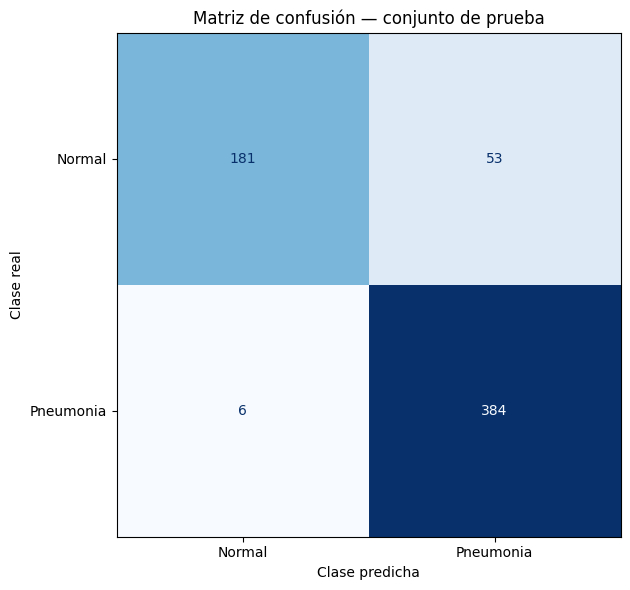

Verdaderos negativos (Normal → Normal): 181
Falsos positivos (Normal → Pneumonia): 53
Falsos negativos (Pneumonia → Normal): 6
Verdaderos positivos (Pneumonia → Pneumonia): 384

==> Métricas del conjunto de prueba
Accuracy:  0.905
Precision: 0.879
Recall:    0.985


In [14]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)

model.eval()
etiquetas_test = []
predicciones_test = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predicciones = outputs.argmax(dim=1).cpu().numpy()

        etiquetas_test.extend(targets.view(-1).cpu().numpy())
        predicciones_test.extend(predicciones)

etiquetas_test = np.asarray(etiquetas_test)
predicciones_test = np.asarray(predicciones_test)

matriz = confusion_matrix(
    etiquetas_test,
    predicciones_test,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))
display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Normal", "Pneumonia"]
)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusión — conjunto de prueba")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz.ravel()
print("Verdaderos negativos (Normal → Normal):", verdaderos_negativos)
print("Falsos positivos (Normal → Pneumonia):", falsos_positivos)
print("Falsos negativos (Pneumonia → Normal):", falsos_negativos)
print("Verdaderos positivos (Pneumonia → Pneumonia):", verdaderos_positivos)

# Pneumonia (clase 1) se considera la clase positiva.
accuracy_test = accuracy_score(etiquetas_test, predicciones_test)
precision_test = precision_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)
recall_test = recall_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)

print("\n==> Métricas del conjunto de prueba")
print(f"Accuracy:  {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall:    {recall_test:.3f}")

## Realizar una predicción individual

In [15]:
def predecir_neumonia(image_tensor):
    """Predice una imagen ya transformada por data_transform."""
    model.eval()
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor.to(DEVICE))
        probabilidades = torch.softmax(outputs, dim=1)[0]
        clase = probabilidades.argmax().item()

    return {
        "clase": "Pneumonia" if clase == 1 else "Normal",
        "probabilidad_normal": probabilidades[0].item(),
        "probabilidad_neumonia": probabilidades[1].item()
    }


for i in range(10):
    imagen_ejemplo, etiqueta_real = test_dataset[i]
    resultado = predecir_neumonia(imagen_ejemplo)

    print("Etiqueta real:", "Pneumonia" if etiqueta_real.item() == 1 else "Normal")
    print("Predicción:", resultado)

Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.9415853369508795e-09, 'probabilidad_neumonia': 1.0}
Etiqueta real: Normal
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 2.428204425086733e-06, 'probabilidad_neumonia': 0.999997615814209}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 3.7296152299859386e-07, 'probabilidad_neumonia': 0.9999996423721313}
Etiqueta real: Normal
Predicción: {'clase': 'Normal', 'probabilidad_normal': 1.0, 'probabilidad_neumonia': 7.86890463899681e-09}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 7.422740200269118e-09, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 2.936413889820244e-10, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 8.091469538840101e-08, 'probabilidad_neumonia': 0.9999998807907104}
Etiqueta rea